In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from lightgbm import LGBMClassifier
from sklearn.cluster import KMeans
sns.set_theme()

In [15]:
df_map = pd.read_csv(
    r'C:\Fause\Programas\EngSoft\repos\ML-Transportes\PBIC\acidentes_pbic_somas.csv',
    encoding='utf-8',
    parse_dates=['data_inversa'],
    dayfirst=True,
    low_memory=False
)

print("Shape inicial:", df_map.shape)


Shape inicial: (1678326, 53)


In [16]:
df_map = df_map.copy()

df_map = df_map.drop_duplicates(subset=["id", "pesid"])

In [17]:
import pandas as pd
import numpy as np
import folium
from folium.plugins import MarkerCluster
from datetime import datetime

# =============================
# Limpeza da BR
# =============================

def limpar_br(df):
    return (
        df["br"]
        .astype(str)
        .str.replace(r'\.0$', '', regex=True)
        .str.replace("BR-", "", regex=False)
        .str.strip()
    )

df_map["br"] = limpar_br(df_map)

# =============================
# FILTRO DE RODOVIA
# =============================

br_escolhida = input("Digite a BR que deseja visualizar (ex: 116) ou pressione ENTER para todas: ")

df_filtrado = df_map.copy()

if br_escolhida.strip() != "":
    df_filtrado = df_filtrado[df_filtrado["br"] == br_escolhida.strip()]
    print(f"Filtrando apenas BR {br_escolhida}")
else:
    print("Mostrando todas as rodovias")

if df_filtrado.empty:
    print("Nenhum dado encontrado para essa BR.")
    exit()

# =============================
# Limpeza coordenadas
# =============================

cols = ["latitude", "longitude", "km"]

for col in cols:
    df_filtrado[col] = pd.to_numeric(
        df_filtrado[col].astype(str).str.replace(",", "."),
        errors="coerce"
    )

df_filtrado = df_filtrado.dropna(subset=["latitude", "longitude", "km"])

# =============================
# KM BIN
# =============================

df_filtrado["km_bin"] = ((df_filtrado["km"] // 5) * 5).astype(int)

# =============================
# Índice de severidade (AGORA FILTRADO)
# =============================

df_filtrado["severity_index"] = (
    4 * df_filtrado["Sum_Mortos"] +
    2 * df_filtrado["Sum_Feridos_Graves"] +
    1 * df_filtrado["Sum_Feridos_Leves"]
)

# =============================
# Agrupamento (AGORA FILTRADO)
# =============================

df_segmento = df_filtrado.groupby(["br", "uf", "km_bin"]).agg(
    severity_index=("severity_index", "mean"),
    n_acidentes=("severity_index", "count"),
    total_mortos=("Sum_Mortos", "sum"),
    total_feridos_graves=("Sum_Feridos_Graves", "sum"),
    total_feridos_leves=("Sum_Feridos_Leves", "sum")
).reset_index()
# =============================
# Classificação de veículos
# =============================

caminhao = ["Caminhão", "Caminhão-trator"]
carros_leves = ["Automóvel"]
caminhonetes = ["Caminhonete", "Camioneta", "Utilitário"]
motos = ["Motocicleta", "Motoneta"]
ciclomotores = ["Ciclomotor", "Triciclo", "Quadriciclo"]

# NOVO 🚍
onibus = ["Ônibus", "Micro-ônibus"]

# =============================
# Criar mapa
# =============================

m = folium.Map(
    location=[df_filtrado["latitude"].median(), df_filtrado["longitude"].median()],
    zoom_start=6
)

# =============================
# Camadas
# =============================

layer_todos = MarkerCluster(name="🔴 Todos acidentes com mortos").add_to(m)
layer_caminhao = MarkerCluster(name="🚛 Caminhões").add_to(m)
layer_carro = MarkerCluster(name="🚗 Automóveis").add_to(m)
layer_caminhonete = MarkerCluster(name="🚙 Caminhonetes").add_to(m)
layer_moto = MarkerCluster(name="🏍 Motocicletas").add_to(m)
layer_ciclomotor = MarkerCluster(name="🛵 Ciclomotores").add_to(m)

# NOVO 🚍
layer_onibus = MarkerCluster(name="🚌 Ônibus").add_to(m)

# =============================
# Agrupamento auxiliar
# =============================

segmentos_grupo = df_filtrado.groupby(["br", "uf", "km_bin"])

# =============================
# Plotagem
# =============================

for _, row in df_segmento.iterrows():

    try:
        grupo = segmentos_grupo.get_group(
            (row["br"], row["uf"], row["km_bin"])
        )
    except KeyError:
        continue

    lat = grupo["latitude"].median()
    lon = grupo["longitude"].median()

    if np.isnan(lat) or np.isnan(lon):
        continue

    # Flags de veículos
    tem_caminhao = grupo["tipo_veiculo"].isin(caminhao).any()
    tem_carro = grupo["tipo_veiculo"].isin(carros_leves).any()
    tem_caminhonete = grupo["tipo_veiculo"].isin(caminhonetes).any()
    tem_moto = grupo["tipo_veiculo"].isin(motos).any()
    tem_ciclomotor = grupo["tipo_veiculo"].isin(ciclomotores).any()
    tem_onibus = grupo["tipo_veiculo"].isin(onibus).any()  # NOVO

    # Popup
    veiculos = grupo["tipo_veiculo"].value_counts().head(3)
    veiculo_txt = "<br>".join([f"{v}: {c}" for v, c in veiculos.items()])

    popup_html = f"""
    <b>BR:</b> {row['br']} - {row['uf']} | <b>KM:</b> {row['km_bin']}<br>
    <b>Total de acidentes:</b> {row['n_acidentes']}<br>
    <b>Total de mortos:</b> {row['total_mortos']}<br>
    <hr><b>Top Veículos:</b><br>{veiculo_txt}
    """

    radius = 7 + (np.log1p(row["total_mortos"]) * 3)

    # Geral
    folium.CircleMarker(
        location=[lat, lon],
        radius=radius,
        color="red",
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(popup_html, max_width=250)
    ).add_to(layer_todos)

    # Camadas específicas
    if tem_caminhao:
        folium.CircleMarker([lat, lon], radius=radius, color="purple", fill=True, fill_opacity=0.7, popup=popup_html).add_to(layer_caminhao)

    if tem_carro:
        folium.CircleMarker([lat, lon], radius=radius, color="blue", fill=True, fill_opacity=0.7, popup=popup_html).add_to(layer_carro)

    if tem_caminhonete:
        folium.CircleMarker([lat, lon], radius=radius, color="darkgreen", fill=True, fill_opacity=0.7, popup=popup_html).add_to(layer_caminhonete)

    if tem_moto:
        folium.CircleMarker([lat, lon], radius=radius, color="orange", fill=True, fill_opacity=0.7, popup=popup_html).add_to(layer_moto)

    if tem_ciclomotor:
        folium.CircleMarker([lat, lon], radius=radius, color="black", fill=True, fill_opacity=0.7, popup=popup_html).add_to(layer_ciclomotor)

    # NOVO 🚍
    if tem_onibus:
        folium.CircleMarker(
            [lat, lon],
            radius=radius,
            color="pink",
            fill=True,
            fill_opacity=0.7,
            popup=popup_html
        ).add_to(layer_onibus)

# =============================
# Controle
# =============================

folium.LayerControl(collapsed=False).add_to(m)

# =============================
# Salvar
# =============================

path = f"C:/Fause/Programas/EngSoft/repos/ML-Transportes/PBIC\EtapaML\Final\MapsCarro/mapa_mortos_carros.html"

m.save(path)

print(f"Mapa gerado com sucesso em: {path}")

<>:210: SyntaxWarning: invalid escape sequence '\E'
<>:210: SyntaxWarning: invalid escape sequence '\E'
C:\Users\fause\AppData\Local\Temp\ipykernel_18812\1520945810.py:210: SyntaxWarning: invalid escape sequence '\E'
  path = f"C:/Fause/Programas/EngSoft/repos/ML-Transportes/PBIC\EtapaML\Final\MapsCarro/mapa_mortos_carros.html"


Mostrando todas as rodovias
Mapa gerado com sucesso em: C:/Fause/Programas/EngSoft/repos/ML-Transportes/PBIC\EtapaML\Final\MapsCarro/mapa_mortos_carros.html


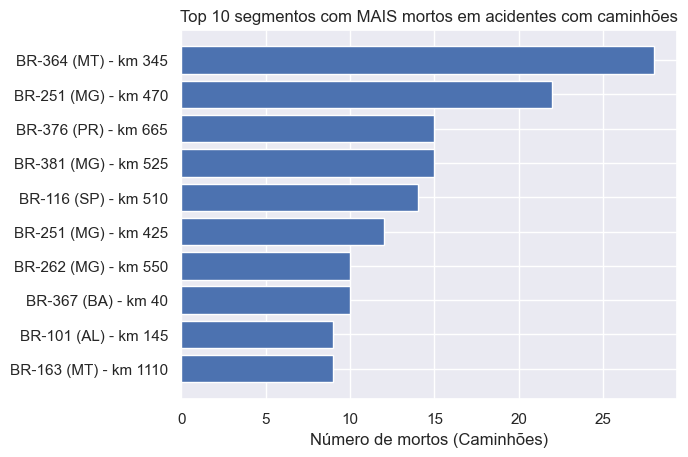

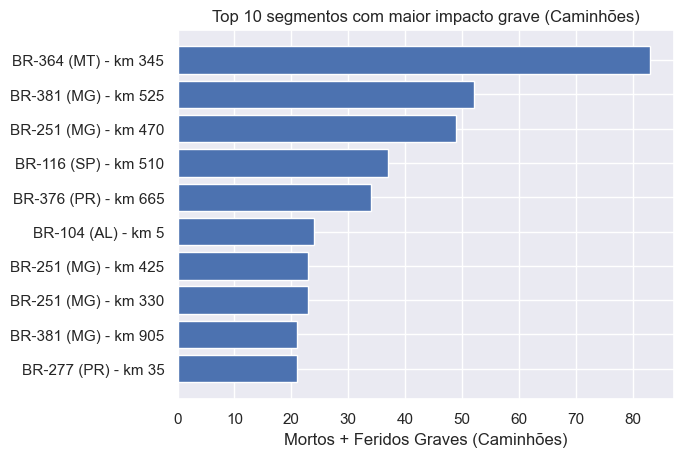

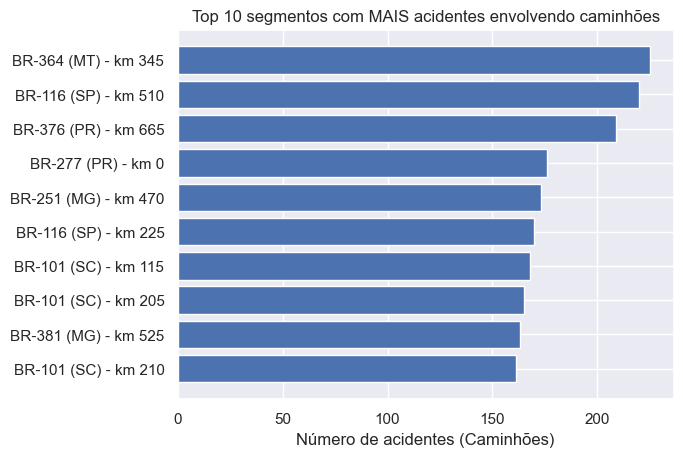

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =============================
# 1️⃣ Definir veículos de caminhão
# =============================

caminhao = ["Caminhão", "Caminhão-trator"]

# =============================
# 2️⃣ Filtrar base original (IMPORTANTE)
# =============================

df_caminhao = df_filtrado[
    df_filtrado["tipo_veiculo"].isin(caminhao)
].copy()

# Segurança: remover linhas inválidas
df_caminhao = df_caminhao.dropna(subset=["br", "uf", "km_bin"])

# =============================
# 3️⃣ Criar índice de severidade
# =============================

df_caminhao["severity_index"] = (
    4 * df_caminhao["Sum_Mortos"] +
    2 * df_caminhao["Sum_Feridos_Graves"] +
    1 * df_caminhao["Sum_Feridos_Leves"]
)

# =============================
# 4️⃣ Agrupar por segmento
# =============================

df_segmento_caminhao = df_caminhao.groupby(
    ["br", "uf", "km_bin"]
).agg(
    n_acidentes=("Sum_Total_Vitimas", "count"),
    total_mortos=("Sum_Mortos", "sum"),
    total_feridos_graves=("Sum_Feridos_Graves", "sum"),
    total_feridos_leves=("Sum_Feridos_Leves", "sum")
).reset_index()

# =============================
# 5️⃣ Criar nome do segmento
# =============================

df_segmento_caminhao["segmento"] = (
    "BR-" + df_segmento_caminhao["br"].astype(str) + " (" +
    df_segmento_caminhao["uf"] + ") - km " +
    df_segmento_caminhao["km_bin"].astype(str)
)

# =============================
# 6️⃣ TOP 10 - MAIS MORTOS (CAMINHÃO)
# =============================

top10_mortos_caminhao = df_segmento_caminhao.sort_values(
    "total_mortos", ascending=False
).head(10)

plt.figure()

plt.barh(
    top10_mortos_caminhao["segmento"],
    top10_mortos_caminhao["total_mortos"]
)

plt.xlabel("Número de mortos (Caminhões)")
plt.title("Top 10 segmentos com MAIS mortos em acidentes com caminhões")
plt.gca().invert_yaxis()

plt.show()

# =============================
# 7️⃣ TOP 10 - IMPACTO GRAVE
# =============================

df_segmento_caminhao["impacto_grave"] = (
    df_segmento_caminhao["total_mortos"] +
    df_segmento_caminhao["total_feridos_graves"]
)

top10_impacto_caminhao = df_segmento_caminhao.sort_values(
    "impacto_grave", ascending=False
).head(10)

plt.figure()

plt.barh(
    top10_impacto_caminhao["segmento"],
    top10_impacto_caminhao["impacto_grave"]
)

plt.xlabel("Mortos + Feridos Graves (Caminhões)")
plt.title("Top 10 segmentos com maior impacto grave (Caminhões)")
plt.gca().invert_yaxis()

plt.show()

# =============================
# 8️⃣ TOP 10 - MAIS ACIDENTES
# =============================

top10_acidentes_caminhao = df_segmento_caminhao.sort_values(
    "n_acidentes", ascending=False
).head(10)

plt.figure()

plt.barh(
    top10_acidentes_caminhao["segmento"],
    top10_acidentes_caminhao["n_acidentes"]
)

plt.xlabel("Número de acidentes (Caminhões)")
plt.title("Top 10 segmentos com MAIS acidentes envolvendo caminhões")
plt.gca().invert_yaxis()

plt.show()

In [25]:
import pandas as pd
import numpy as np
import folium
from folium.plugins import MarkerCluster

# =============================
# 1️⃣ FILTRO - CAMINHÕES
# =============================

caminhao = ["Caminhão", "Caminhão-trator"]

df_caminhao = df_filtrado[
    df_filtrado["tipo_veiculo"].isin(caminhao)
].copy()

# =============================
# 2️⃣ LIMPEZA
# =============================

df_caminhao = df_caminhao.dropna(subset=["latitude", "longitude", "km"])

# =============================
# 3️⃣ KM BIN
# =============================

df_caminhao["km_bin"] = ((df_caminhao["km"] // 5) * 5).astype(int)

# =============================
# 4️⃣ AGRUPAMENTO
# =============================

df_segmento_caminhao = df_caminhao.groupby(
    ["br", "uf", "km_bin"]
).agg(
    total_mortos=("Sum_Mortos", "sum"),
    total_feridos_graves=("Sum_Feridos_Graves", "sum"),
    total_feridos_leves=("Sum_Feridos_Leves", "sum")
).reset_index()

# =============================
# 5️⃣ IMPACTO GRAVE
# =============================

df_segmento_caminhao["impacto_grave"] = (
    df_segmento_caminhao["total_mortos"] +
    df_segmento_caminhao["total_feridos_graves"]
)

# =============================
# 6️⃣ TOP 10 (IGUAL AO HISTOGRAMA)
# =============================

top10 = df_segmento_caminhao.sort_values(
    "impacto_grave", ascending=False
).head(10)

# =============================
# 7️⃣ AGRUPAMENTO AUXILIAR (dados brutos)
# =============================

segmentos_grupo = df_caminhao.groupby(["br", "uf", "km_bin"])

# =============================
# 8️⃣ MAPA
# =============================

m = folium.Map(
    location=[df_caminhao["latitude"].median(), df_caminhao["longitude"].median()],
    zoom_start=6
)

layer_top10 = MarkerCluster(name="🚛 Top 10 Caminhões (Impacto Grave)").add_to(m)

# =============================
# 9️⃣ PLOTAGEM
# =============================

for _, row in top10.iterrows():

    try:
        grupo = segmentos_grupo.get_group(
            (row["br"], row["uf"], row["km_bin"])
        )
    except KeyError:
        continue

    lat = grupo["latitude"].median()
    lon = grupo["longitude"].median()

    if np.isnan(lat) or np.isnan(lon):
        continue

    # Top veículos
    veiculos = grupo["tipo_veiculo"].value_counts().head(3)
    veiculo_txt = "<br>".join([f"{v}: {c}" for v, c in veiculos.items()])

    # =============================
    # POPUP (CORRIGIDO)
    # =============================

    popup_html = f"""
    <b>🚛 TOP SEGMENTO CAMINHÕES</b><br>
    <hr>
    <b>BR:</b> {row['br']} - {row['uf']}<br>
    <b>KM:</b> {row['km_bin']}<br>
    <hr>
    <b>Acidentes:</b> {grupo.shape[0]}<br>
    <b>Mortos:</b> {row['total_mortos']}<br>
    <b>Feridos Graves:</b> {row['total_feridos_graves']}<br>
    <b>Impacto Grave:</b> {row['impacto_grave']}<br>
    <hr>
    <b>Top Veículos:</b><br>
    {veiculo_txt}
    """

    # tamanho proporcional ao impacto
    radius = 10 + np.log1p(row["impacto_grave"]) * 5

    folium.CircleMarker(
        location=[lat, lon],
        radius=radius,
        color="purple",
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(popup_html, max_width=300)
    ).add_to(layer_top10)

# =============================
# 10️⃣ CONTROLE
# =============================

folium.LayerControl(collapsed=False).add_to(m)

# =============================
# 9️⃣ Salvar
# =============================
path = f"C:/Fause/Programas/EngSoft/repos/ML-Transportes/PBIC\EtapaML\Final\MapsCarro/mapa_top10_impacto_caminhoes.html"
m.save(path)

print(f"Mapa TOP 10 caminhões salvo em: {path}")

<>:137: SyntaxWarning: invalid escape sequence '\E'
<>:137: SyntaxWarning: invalid escape sequence '\E'
C:\Users\fause\AppData\Local\Temp\ipykernel_18812\2236357796.py:137: SyntaxWarning: invalid escape sequence '\E'
  path = f"C:/Fause/Programas/EngSoft/repos/ML-Transportes/PBIC\EtapaML\Final\MapsCarro/mapa_top10_impacto_caminhoes.html"


Mapa TOP 10 caminhões salvo em: C:/Fause/Programas/EngSoft/repos/ML-Transportes/PBIC\EtapaML\Final\MapsCarro/mapa_top10_impacto_caminhoes.html


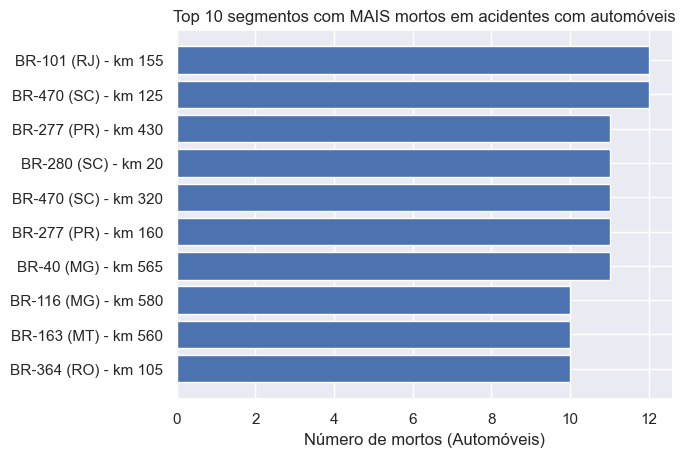

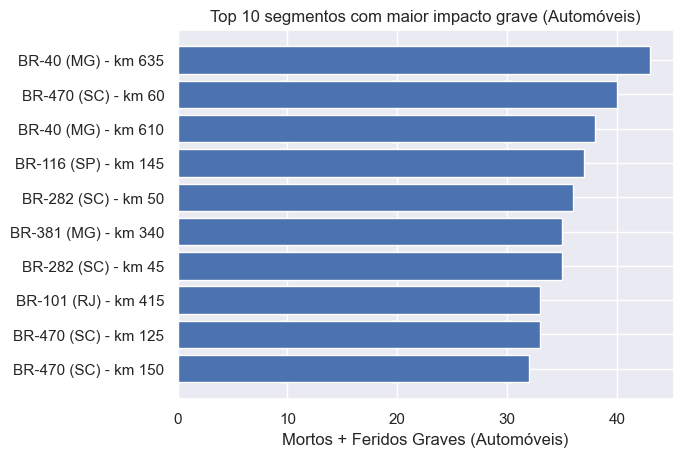

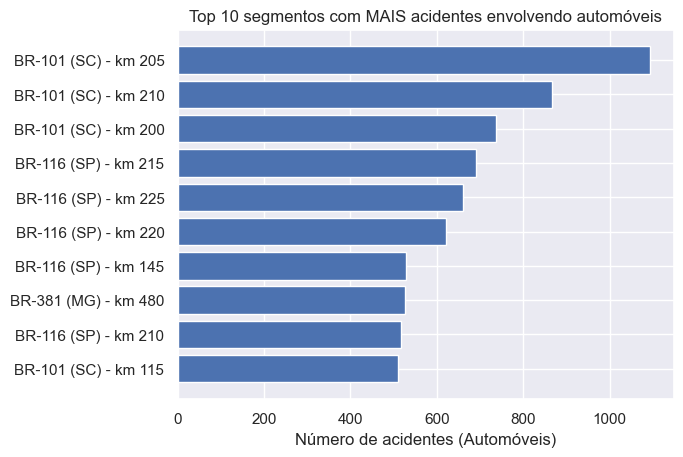

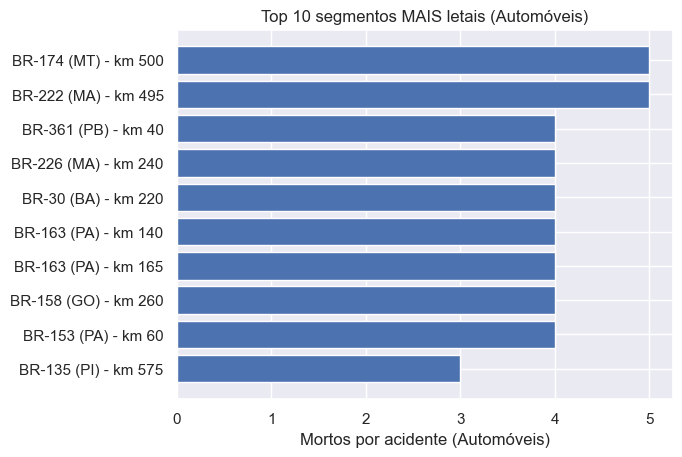

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =============================
# 1️⃣ Definir veículos leves
# =============================

carros_leves = ["Automóvel"]

# =============================
# 2️⃣ Filtrar base original
# =============================

df_carro = df_filtrado[
    df_filtrado["tipo_veiculo"].isin(carros_leves)
].copy()

# Remover possíveis inconsistências
df_carro = df_carro.dropna(subset=["br", "uf", "km_bin"])

# =============================
# 3️⃣ Criar índice de severidade
# =============================

df_carro["severity_index"] = (
    4 * df_carro["Sum_Mortos"] +
    2 * df_carro["Sum_Feridos_Graves"] +
    1 * df_carro["Sum_Feridos_Leves"]
)

# =============================
# 4️⃣ Agrupar por segmento
# =============================

df_segmento_carro = df_carro.groupby(
    ["br", "uf", "km_bin"]
).agg(
    n_acidentes=("Sum_Total_Vitimas", "count"),
    total_mortos=("Sum_Mortos", "sum"),
    total_feridos_graves=("Sum_Feridos_Graves", "sum"),
    total_feridos_leves=("Sum_Feridos_Leves", "sum")
).reset_index()

# =============================
# 5️⃣ Criar nome do segmento
# =============================

df_segmento_carro["segmento"] = (
    "BR-" + df_segmento_carro["br"].astype(str) + " (" +
    df_segmento_carro["uf"] + ") - km " +
    df_segmento_carro["km_bin"].astype(str)
)

# =============================
# 6️⃣ TOP 10 - MAIS MORTOS (CARROS)
# =============================

top10_mortos_carro = df_segmento_carro.sort_values(
    "total_mortos", ascending=False
).head(10)

plt.figure()

plt.barh(
    top10_mortos_carro["segmento"],
    top10_mortos_carro["total_mortos"]
)

plt.xlabel("Número de mortos (Automóveis)")
plt.title("Top 10 segmentos com MAIS mortos em acidentes com automóveis")
plt.gca().invert_yaxis()

plt.show()

# =============================
# 7️⃣ TOP 10 - IMPACTO GRAVE
# =============================

df_segmento_carro["impacto_grave"] = (
    df_segmento_carro["total_mortos"] +
    df_segmento_carro["total_feridos_graves"]
)

top10_impacto_carro = df_segmento_carro.sort_values(
    "impacto_grave", ascending=False
).head(10)

plt.figure()

plt.barh(
    top10_impacto_carro["segmento"],
    top10_impacto_carro["impacto_grave"]
)

plt.xlabel("Mortos + Feridos Graves (Automóveis)")
plt.title("Top 10 segmentos com maior impacto grave (Automóveis)")
plt.gca().invert_yaxis()

plt.show()

# =============================
# 8️⃣ TOP 10 - MAIS ACIDENTES
# =============================

top10_acidentes_carro = df_segmento_carro.sort_values(
    "n_acidentes", ascending=False
).head(10)

plt.figure()

plt.barh(
    top10_acidentes_carro["segmento"],
    top10_acidentes_carro["n_acidentes"]
)

plt.xlabel("Número de acidentes (Automóveis)")
plt.title("Top 10 segmentos com MAIS acidentes envolvendo automóveis")
plt.gca().invert_yaxis()

plt.show()

# =============================
# 9️⃣ EXTRA - TAXA DE RISCO
# =============================

df_segmento_carro["mortos_por_acidente"] = (
    df_segmento_carro["total_mortos"] /
    df_segmento_carro["n_acidentes"].replace(0, np.nan)
)

top10_risco_carro = df_segmento_carro.sort_values(
    "mortos_por_acidente", ascending=False
).head(10)

plt.figure()

plt.barh(
    top10_risco_carro["segmento"],
    top10_risco_carro["mortos_por_acidente"]
)

plt.xlabel("Mortos por acidente (Automóveis)")
plt.title("Top 10 segmentos MAIS letais (Automóveis)")
plt.gca().invert_yaxis()

plt.show()

In [26]:
import pandas as pd
import numpy as np
import folium
from folium.plugins import MarkerCluster

# =============================
# 1️⃣ FILTRO - AUTOMÓVEIS
# =============================

carros_leves = ["Automóvel"]

df_carro = df_filtrado[
    df_filtrado["tipo_veiculo"].isin(carros_leves)
].copy()

# =============================
# 2️⃣ LIMPEZA
# =============================

df_carro = df_carro.dropna(subset=["latitude", "longitude", "km"])

# =============================
# 3️⃣ KM BIN
# =============================

df_carro["km_bin"] = ((df_carro["km"] // 5) * 5).astype(int)

# =============================
# 4️⃣ AGRUPAMENTO
# =============================

df_segmento_carro = df_carro.groupby(
    ["br", "uf", "km_bin"]
).agg(
    total_mortos=("Sum_Mortos", "sum"),
    total_feridos_graves=("Sum_Feridos_Graves", "sum"),
    total_feridos_leves=("Sum_Feridos_Leves", "sum")
).reset_index()

# =============================
# 5️⃣ IMPACTO GRAVE
# =============================

df_segmento_carro["impacto_grave"] = (
    df_segmento_carro["total_mortos"] +
    df_segmento_carro["total_feridos_graves"]
)

# =============================
# 6️⃣ TOP 10 (IGUAL AO HISTOGRAMA)
# =============================

top10 = df_segmento_carro.sort_values(
    "impacto_grave", ascending=False
).head(10)

# =============================
# 7️⃣ AGRUPAMENTO AUXILIAR
# =============================

segmentos_grupo = df_carro.groupby(["br", "uf", "km_bin"])

# =============================
# 8️⃣ MAPA
# =============================

m = folium.Map(
    location=[df_carro["latitude"].median(), df_carro["longitude"].median()],
    zoom_start=6
)

layer_top10 = MarkerCluster(name="🚗 Top 10 Automóveis (Impacto Grave)").add_to(m)

# =============================
# 9️⃣ PLOTAGEM
# =============================

for _, row in top10.iterrows():

    try:
        grupo = segmentos_grupo.get_group(
            (row["br"], row["uf"], row["km_bin"])
        )
    except KeyError:
        continue

    lat = grupo["latitude"].median()
    lon = grupo["longitude"].median()

    if np.isnan(lat) or np.isnan(lon):
        continue

    # Top veículos (mesmo sendo carro, pode aparecer outros envolvidos)
    veiculos = grupo["tipo_veiculo"].value_counts().head(3)
    veiculo_txt = "<br>".join([f"{v}: {c}" for v, c in veiculos.items()])

    # =============================
    # POPUP
    # =============================

    popup_html = f"""
    <b>🚗 TOP SEGMENTO AUTOMÓVEIS</b><br>
    <hr>
    <b>BR:</b> {row['br']} - {row['uf']}<br>
    <b>KM:</b> {row['km_bin']}<br>
    <hr>
    <b>Acidentes:</b> {grupo.shape[0]}<br>
    <b>Mortos:</b> {row['total_mortos']}<br>
    <b>Feridos Graves:</b> {row['total_feridos_graves']}<br>
    <b>Impacto Grave:</b> {row['impacto_grave']}<br>
    <hr>
    <b>Top Veículos:</b><br>
    {veiculo_txt}
    """

    # tamanho proporcional ao impacto
    radius = 10 + np.log1p(row["impacto_grave"]) * 5

    folium.CircleMarker(
        location=[lat, lon],
        radius=radius,
        color="blue",
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(popup_html, max_width=300)
    ).add_to(layer_top10)

# =============================
# 🔟 CONTROLE
# =============================

folium.LayerControl(collapsed=False).add_to(m)

# =============================
# 9️⃣ Salvar
# =============================
path = f"C:/Fause/Programas/EngSoft/repos/ML-Transportes/PBIC\EtapaML\Final\MapsCarro/mapa_top10_automoveis.html"
m.save(path)

print(f"Mapa TOP 10 caminhões salvo em: {path}")

<>:137: SyntaxWarning: invalid escape sequence '\E'
<>:137: SyntaxWarning: invalid escape sequence '\E'
C:\Users\fause\AppData\Local\Temp\ipykernel_18812\3612560083.py:137: SyntaxWarning: invalid escape sequence '\E'
  path = f"C:/Fause/Programas/EngSoft/repos/ML-Transportes/PBIC\EtapaML\Final\MapsCarro/mapa_top10_automoveis.html"


Mapa TOP 10 caminhões salvo em: C:/Fause/Programas/EngSoft/repos/ML-Transportes/PBIC\EtapaML\Final\MapsCarro/mapa_top10_automoveis.html


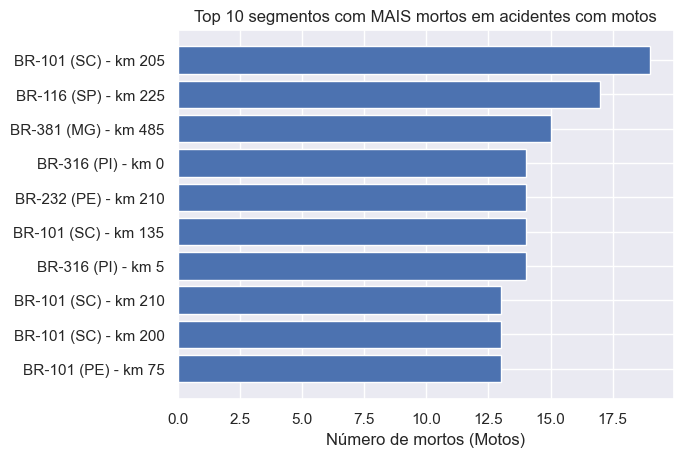

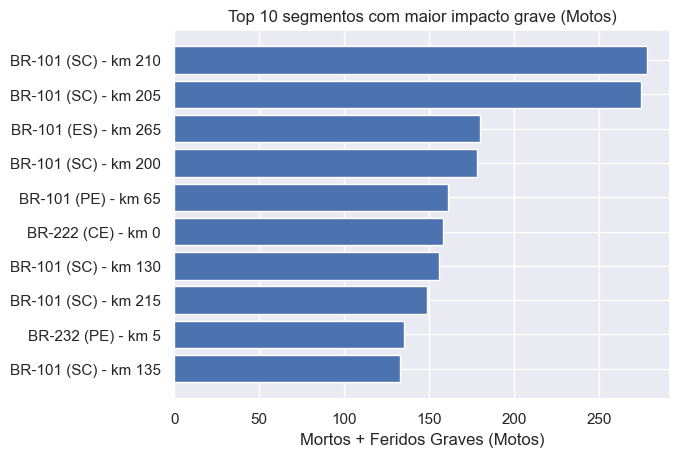

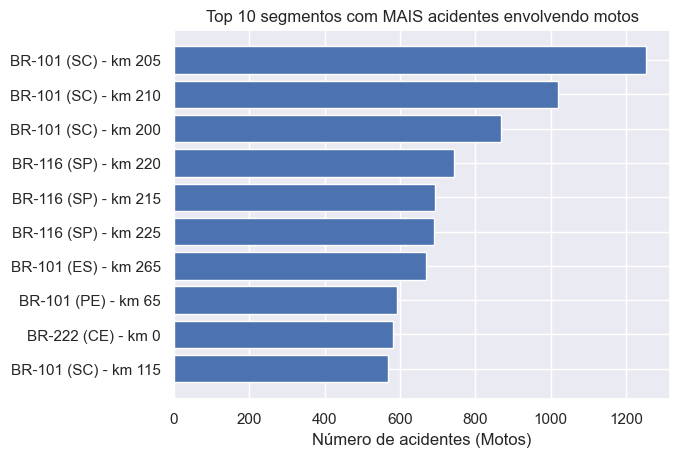

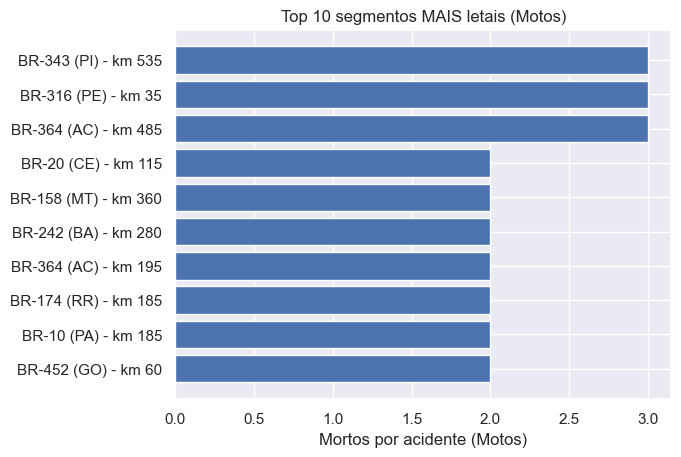

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =============================
# 1️⃣ Definir veículos (motos)
# =============================

motos = ["Motocicleta", "Motoneta"]

# =============================
# 2️⃣ Filtrar base original
# =============================

df_moto = df_filtrado[
    df_filtrado["tipo_veiculo"].isin(motos)
].copy()

# Remover possíveis inconsistências
df_moto = df_moto.dropna(subset=["br", "uf", "km_bin"])

# =============================
# 3️⃣ Criar índice de severidade
# =============================

df_moto["severity_index"] = (
    4 * df_moto["Sum_Mortos"] +
    2 * df_moto["Sum_Feridos_Graves"] +
    1 * df_moto["Sum_Feridos_Leves"]
)

# =============================
# 4️⃣ Agrupar por segmento
# =============================

df_segmento_moto = df_moto.groupby(
    ["br", "uf", "km_bin"]
).agg(
    n_acidentes=("Sum_Total_Vitimas", "count"),
    total_mortos=("Sum_Mortos", "sum"),
    total_feridos_graves=("Sum_Feridos_Graves", "sum"),
    total_feridos_leves=("Sum_Feridos_Leves", "sum")
).reset_index()

# =============================
# 5️⃣ Criar nome do segmento
# =============================

df_segmento_moto["segmento"] = (
    "BR-" + df_segmento_moto["br"].astype(str) + " (" +
    df_segmento_moto["uf"] + ") - km " +
    df_segmento_moto["km_bin"].astype(str)
)

# =============================
# 6️⃣ TOP 10 - MAIS MORTOS (MOTOS)
# =============================

top10_mortos_moto = df_segmento_moto.sort_values(
    "total_mortos", ascending=False
).head(10)

plt.figure()

plt.barh(
    top10_mortos_moto["segmento"],
    top10_mortos_moto["total_mortos"]
)

plt.xlabel("Número de mortos (Motos)")
plt.title("Top 10 segmentos com MAIS mortos em acidentes com motos")
plt.gca().invert_yaxis()

plt.show()

# =============================
# 7️⃣ TOP 10 - IMPACTO GRAVE
# =============================

df_segmento_moto["impacto_grave"] = (
    df_segmento_moto["total_mortos"] +
    df_segmento_moto["total_feridos_graves"]
)

top10_impacto_moto = df_segmento_moto.sort_values(
    "impacto_grave", ascending=False
).head(10)

plt.figure()

plt.barh(
    top10_impacto_moto["segmento"],
    top10_impacto_moto["impacto_grave"]
)

plt.xlabel("Mortos + Feridos Graves (Motos)")
plt.title("Top 10 segmentos com maior impacto grave (Motos)")
plt.gca().invert_yaxis()

plt.show()

# =============================
# 8️⃣ TOP 10 - MAIS ACIDENTES
# =============================

top10_acidentes_moto = df_segmento_moto.sort_values(
    "n_acidentes", ascending=False
).head(10)

plt.figure()

plt.barh(
    top10_acidentes_moto["segmento"],
    top10_acidentes_moto["n_acidentes"]
)

plt.xlabel("Número de acidentes (Motos)")
plt.title("Top 10 segmentos com MAIS acidentes envolvendo motos")
plt.gca().invert_yaxis()

plt.show()

# =============================
# 9️⃣ EXTRA - TAXA DE RISCO
# =============================

df_segmento_moto["mortos_por_acidente"] = (
    df_segmento_moto["total_mortos"] /
    df_segmento_moto["n_acidentes"].replace(0, np.nan)
)

top10_risco_moto = df_segmento_moto.sort_values(
    "mortos_por_acidente", ascending=False
).head(10)

plt.figure()

plt.barh(
    top10_risco_moto["segmento"],
    top10_risco_moto["mortos_por_acidente"]
)

plt.xlabel("Mortos por acidente (Motos)")
plt.title("Top 10 segmentos MAIS letais (Motos)")
plt.gca().invert_yaxis()

plt.show()

In [27]:
import pandas as pd
import numpy as np
import folium
from folium.plugins import MarkerCluster

# =============================
# 1️⃣ FILTRO - MOTOS
# =============================

motos = ["Motocicleta", "Motoneta"]

df_moto = df_filtrado[
    df_filtrado["tipo_veiculo"].isin(motos)
].copy()

# =============================
# 2️⃣ LIMPEZA
# =============================

df_moto = df_moto.dropna(subset=["latitude", "longitude", "km"])

# =============================
# 3️⃣ KM BIN
# =============================

df_moto["km_bin"] = ((df_moto["km"] // 5) * 5).astype(int)

# =============================
# 4️⃣ AGRUPAMENTO
# =============================

df_segmento_moto = df_moto.groupby(
    ["br", "uf", "km_bin"]
).agg(
    total_mortos=("Sum_Mortos", "sum"),
    total_feridos_graves=("Sum_Feridos_Graves", "sum"),
    total_feridos_leves=("Sum_Feridos_Leves", "sum")
).reset_index()

# =============================
# 5️⃣ IMPACTO GRAVE
# =============================

df_segmento_moto["impacto_grave"] = (
    df_segmento_moto["total_mortos"] +
    df_segmento_moto["total_feridos_graves"]
)

# =============================
# 6️⃣ TOP 10 (IGUAL AO HISTOGRAMA)
# =============================

top10 = df_segmento_moto.sort_values(
    "impacto_grave", ascending=False
).head(10)

# =============================
# 7️⃣ AGRUPAMENTO AUXILIAR
# =============================

segmentos_grupo = df_moto.groupby(["br", "uf", "km_bin"])

# =============================
# 8️⃣ MAPA
# =============================

m = folium.Map(
    location=[df_moto["latitude"].median(), df_moto["longitude"].median()],
    zoom_start=6
)

layer_top10 = MarkerCluster(name="🏍 Top 10 Motos (Impacto Grave)").add_to(m)

# =============================
# 9️⃣ PLOTAGEM
# =============================

for _, row in top10.iterrows():

    try:
        grupo = segmentos_grupo.get_group(
            (row["br"], row["uf"], row["km_bin"])
        )
    except KeyError:
        continue

    lat = grupo["latitude"].median()
    lon = grupo["longitude"].median()

    if np.isnan(lat) or np.isnan(lon):
        continue

    # Top veículos (interações com outros veículos)
    veiculos = grupo["tipo_veiculo"].value_counts().head(3)
    veiculo_txt = "<br>".join([f"{v}: {c}" for v, c in veiculos.items()])

    # =============================
    # POPUP
    # =============================

    popup_html = f"""
    <b>🏍 TOP SEGMENTO MOTOS</b><br>
    <hr>
    <b>BR:</b> {row['br']} - {row['uf']}<br>
    <b>KM:</b> {row['km_bin']}<br>
    <hr>
    <b>Acidentes:</b> {grupo.shape[0]}<br>
    <b>Mortos:</b> {row['total_mortos']}<br>
    <b>Feridos Graves:</b> {row['total_feridos_graves']}<br>
    <b>Impacto Grave:</b> {row['impacto_grave']}<br>
    <hr>
    <b>Top Veículos:</b><br>
    {veiculo_txt}
    """

    # tamanho proporcional ao impacto
    radius = 10 + np.log1p(row["impacto_grave"]) * 5

    folium.CircleMarker(
        location=[lat, lon],
        radius=radius,
        color="orange",
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(popup_html, max_width=300)
    ).add_to(layer_top10)

# =============================
# 🔟 CONTROLE
# =============================

folium.LayerControl(collapsed=False).add_to(m)

# =============================
# 9️⃣ Salvar
# =============================
path = f"C:/Fause/Programas/EngSoft/repos/ML-Transportes/PBIC\EtapaML\Final\MapsCarro/mapa_top10_motos.html"
m.save(path)

print(f"Mapa TOP 10 caminhões salvo em: {path}")

<>:137: SyntaxWarning: invalid escape sequence '\E'
<>:137: SyntaxWarning: invalid escape sequence '\E'
C:\Users\fause\AppData\Local\Temp\ipykernel_18812\3190036530.py:137: SyntaxWarning: invalid escape sequence '\E'
  path = f"C:/Fause/Programas/EngSoft/repos/ML-Transportes/PBIC\EtapaML\Final\MapsCarro/mapa_top10_motos.html"


Mapa TOP 10 caminhões salvo em: C:/Fause/Programas/EngSoft/repos/ML-Transportes/PBIC\EtapaML\Final\MapsCarro/mapa_top10_motos.html


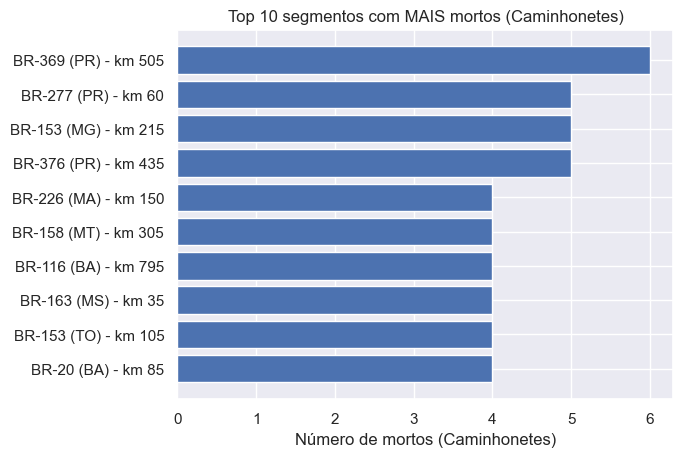

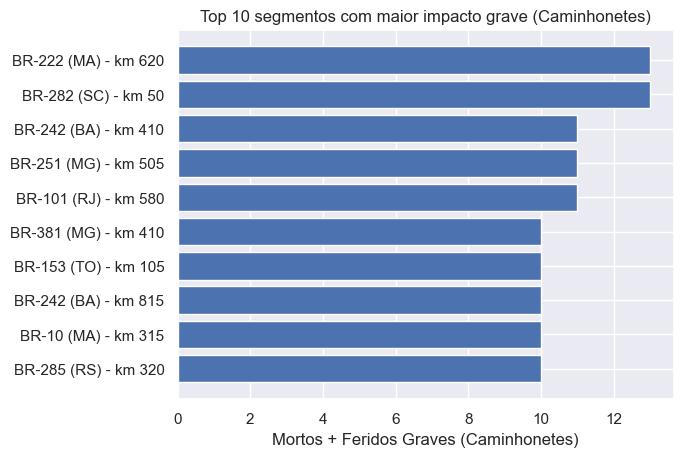

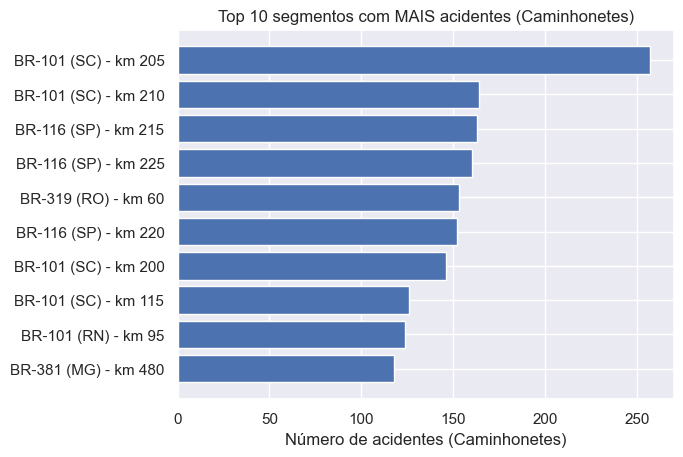

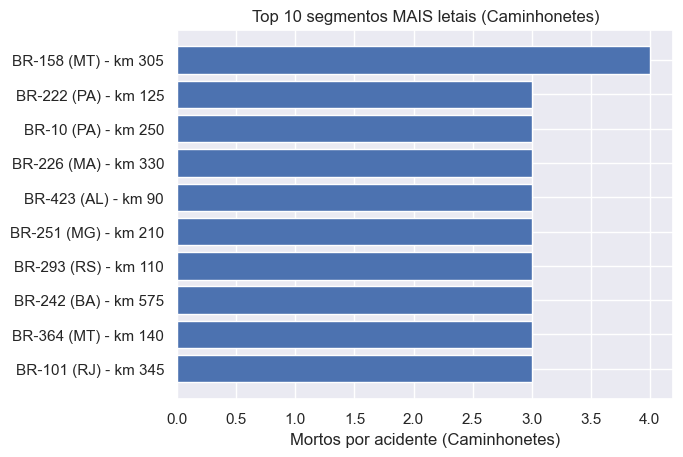

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =============================
# 1️⃣ Definir veículos
# =============================

caminhonetes = ["Caminhonete", "Camioneta", "Utilitário"]

# =============================
# 2️⃣ Filtrar base original
# =============================

df_caminhonete = df_filtrado[
    df_filtrado["tipo_veiculo"].isin(caminhonetes)
].copy()

# Remover possíveis inconsistências
df_caminhonete = df_caminhonete.dropna(subset=["br", "uf", "km_bin"])

# =============================
# 3️⃣ Criar índice de severidade
# =============================

df_caminhonete["severity_index"] = (
    4 * df_caminhonete["Sum_Mortos"] +
    2 * df_caminhonete["Sum_Feridos_Graves"] +
    1 * df_caminhonete["Sum_Feridos_Leves"]
)

# =============================
# 4️⃣ Agrupar por segmento
# =============================

df_segmento_caminhonete = df_caminhonete.groupby(
    ["br", "uf", "km_bin"]
).agg(
    n_acidentes=("Sum_Total_Vitimas", "count"),
    total_mortos=("Sum_Mortos", "sum"),
    total_feridos_graves=("Sum_Feridos_Graves", "sum"),
    total_feridos_leves=("Sum_Feridos_Leves", "sum")
).reset_index()

# =============================
# 5️⃣ Criar nome do segmento
# =============================

df_segmento_caminhonete["segmento"] = (
    "BR-" + df_segmento_caminhonete["br"].astype(str) + " (" +
    df_segmento_caminhonete["uf"] + ") - km " +
    df_segmento_caminhonete["km_bin"].astype(str)
)

# =============================
# 6️⃣ TOP 10 - MAIS MORTOS
# =============================

top10_mortos_caminhonete = df_segmento_caminhonete.sort_values(
    "total_mortos", ascending=False
).head(10)

plt.figure()

plt.barh(
    top10_mortos_caminhonete["segmento"],
    top10_mortos_caminhonete["total_mortos"]
)

plt.xlabel("Número de mortos (Caminhonetes)")
plt.title("Top 10 segmentos com MAIS mortos (Caminhonetes)")
plt.gca().invert_yaxis()

plt.show()

# =============================
# 7️⃣ TOP 10 - IMPACTO GRAVE
# =============================

df_segmento_caminhonete["impacto_grave"] = (
    df_segmento_caminhonete["total_mortos"] +
    df_segmento_caminhonete["total_feridos_graves"]
)

top10_impacto_caminhonete = df_segmento_caminhonete.sort_values(
    "impacto_grave", ascending=False
).head(10)

plt.figure()

plt.barh(
    top10_impacto_caminhonete["segmento"],
    top10_impacto_caminhonete["impacto_grave"]
)

plt.xlabel("Mortos + Feridos Graves (Caminhonetes)")
plt.title("Top 10 segmentos com maior impacto grave (Caminhonetes)")
plt.gca().invert_yaxis()

plt.show()

# =============================
# 8️⃣ TOP 10 - MAIS ACIDENTES
# =============================

top10_acidentes_caminhonete = df_segmento_caminhonete.sort_values(
    "n_acidentes", ascending=False
).head(10)

plt.figure()

plt.barh(
    top10_acidentes_caminhonete["segmento"],
    top10_acidentes_caminhonete["n_acidentes"]
)

plt.xlabel("Número de acidentes (Caminhonetes)")
plt.title("Top 10 segmentos com MAIS acidentes (Caminhonetes)")
plt.gca().invert_yaxis()

plt.show()

# =============================
# 9️⃣ EXTRA - TAXA DE RISCO
# =============================

df_segmento_caminhonete["mortos_por_acidente"] = (
    df_segmento_caminhonete["total_mortos"] /
    df_segmento_caminhonete["n_acidentes"].replace(0, np.nan)
)

top10_risco_caminhonete = df_segmento_caminhonete.sort_values(
    "mortos_por_acidente", ascending=False
).head(10)

plt.figure()

plt.barh(
    top10_risco_caminhonete["segmento"],
    top10_risco_caminhonete["mortos_por_acidente"]
)

plt.xlabel("Mortos por acidente (Caminhonetes)")
plt.title("Top 10 segmentos MAIS letais (Caminhonetes)")
plt.gca().invert_yaxis()

plt.show()

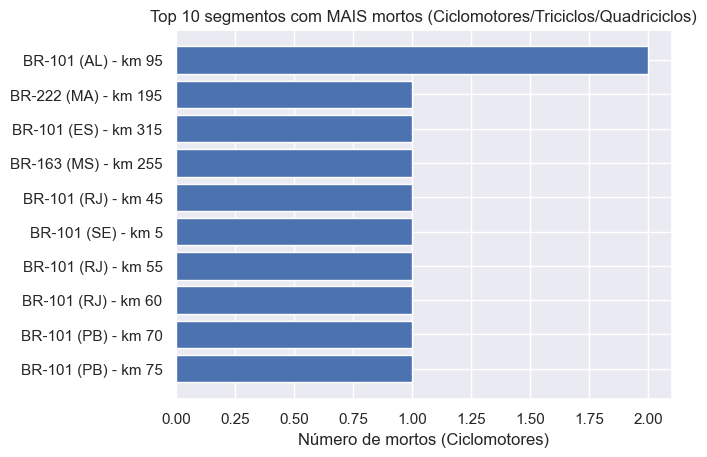

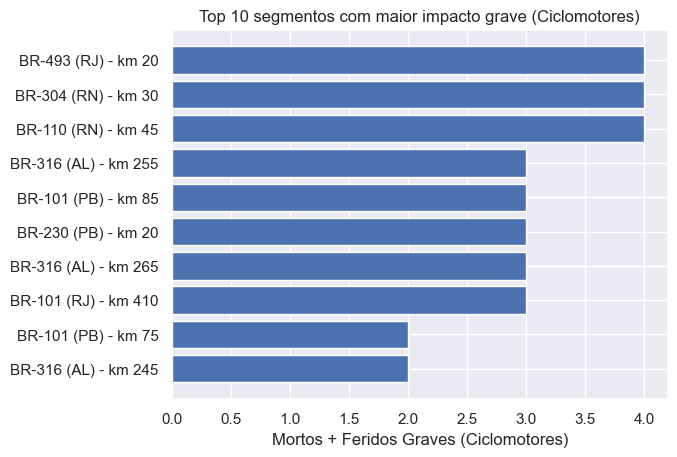

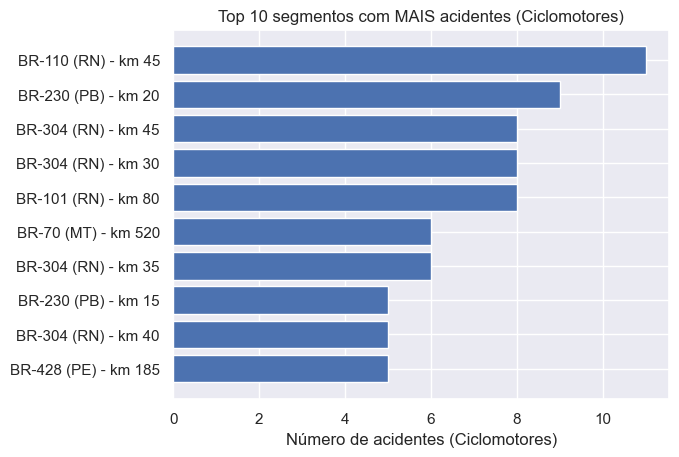

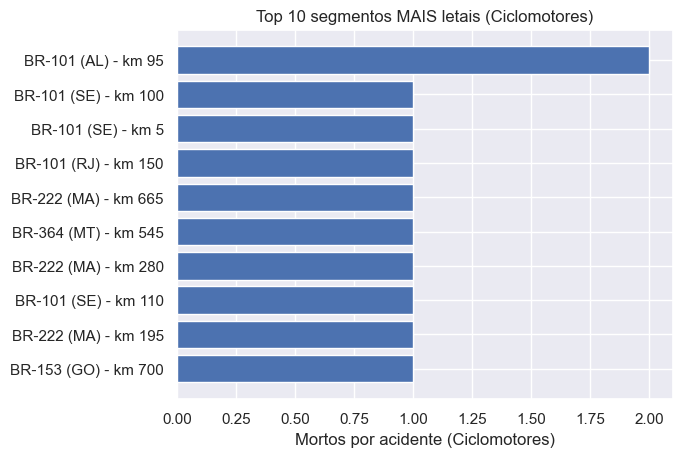

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =============================
# 1️⃣ Definir veículos
# =============================

ciclomotores = ["Ciclomotor", "Triciclo", "Quadriciclo"]

# =============================
# 2️⃣ Filtrar base original
# =============================

df_ciclo = df_filtrado[
    df_filtrado["tipo_veiculo"].isin(ciclomotores)
].copy()

# Remover possíveis inconsistências
df_ciclo = df_ciclo.dropna(subset=["br", "uf", "km_bin"])

# =============================
# 3️⃣ Criar índice de severidade
# =============================

df_ciclo["severity_index"] = (
    4 * df_ciclo["Sum_Mortos"] +
    2 * df_ciclo["Sum_Feridos_Graves"] +
    1 * df_ciclo["Sum_Feridos_Leves"]
)

# =============================
# 4️⃣ Agrupar por segmento
# =============================

df_segmento_ciclo = df_ciclo.groupby(
    ["br", "uf", "km_bin"]
).agg(
    n_acidentes=("Sum_Total_Vitimas", "count"),
    total_mortos=("Sum_Mortos", "sum"),
    total_feridos_graves=("Sum_Feridos_Graves", "sum"),
    total_feridos_leves=("Sum_Feridos_Leves", "sum")
).reset_index()

# =============================
# 5️⃣ Criar nome do segmento
# =============================

df_segmento_ciclo["segmento"] = (
    "BR-" + df_segmento_ciclo["br"].astype(str) + " (" +
    df_segmento_ciclo["uf"] + ") - km " +
    df_segmento_ciclo["km_bin"].astype(str)
)

# =============================
# 6️⃣ TOP 10 - MAIS MORTOS
# =============================

top10_mortos_ciclo = df_segmento_ciclo.sort_values(
    "total_mortos", ascending=False
).head(10)

plt.figure()

plt.barh(
    top10_mortos_ciclo["segmento"],
    top10_mortos_ciclo["total_mortos"]
)

plt.xlabel("Número de mortos (Ciclomotores)")
plt.title("Top 10 segmentos com MAIS mortos (Ciclomotores/Triciclos/Quadriciclos)")
plt.gca().invert_yaxis()

plt.show()

# =============================
# 7️⃣ TOP 10 - IMPACTO GRAVE
# =============================

df_segmento_ciclo["impacto_grave"] = (
    df_segmento_ciclo["total_mortos"] +
    df_segmento_ciclo["total_feridos_graves"]
)

top10_impacto_ciclo = df_segmento_ciclo.sort_values(
    "impacto_grave", ascending=False
).head(10)

plt.figure()

plt.barh(
    top10_impacto_ciclo["segmento"],
    top10_impacto_ciclo["impacto_grave"]
)

plt.xlabel("Mortos + Feridos Graves (Ciclomotores)")
plt.title("Top 10 segmentos com maior impacto grave (Ciclomotores)")
plt.gca().invert_yaxis()

plt.show()

# =============================
# 8️⃣ TOP 10 - MAIS ACIDENTES
# =============================

top10_acidentes_ciclo = df_segmento_ciclo.sort_values(
    "n_acidentes", ascending=False
).head(10)

plt.figure()

plt.barh(
    top10_acidentes_ciclo["segmento"],
    top10_acidentes_ciclo["n_acidentes"]
)

plt.xlabel("Número de acidentes (Ciclomotores)")
plt.title("Top 10 segmentos com MAIS acidentes (Ciclomotores)")
plt.gca().invert_yaxis()

plt.show()

# =============================
# 9️⃣ EXTRA - TAXA DE RISCO
# =============================

df_segmento_ciclo["mortos_por_acidente"] = (
    df_segmento_ciclo["total_mortos"] /
    df_segmento_ciclo["n_acidentes"].replace(0, np.nan)
)

top10_risco_ciclo = df_segmento_ciclo.sort_values(
    "mortos_por_acidente", ascending=False
).head(10)

plt.figure()

plt.barh(
    top10_risco_ciclo["segmento"],
    top10_risco_ciclo["mortos_por_acidente"]
)

plt.xlabel("Mortos por acidente (Ciclomotores)")
plt.title("Top 10 segmentos MAIS letais (Ciclomotores)")
plt.gca().invert_yaxis()

plt.show()

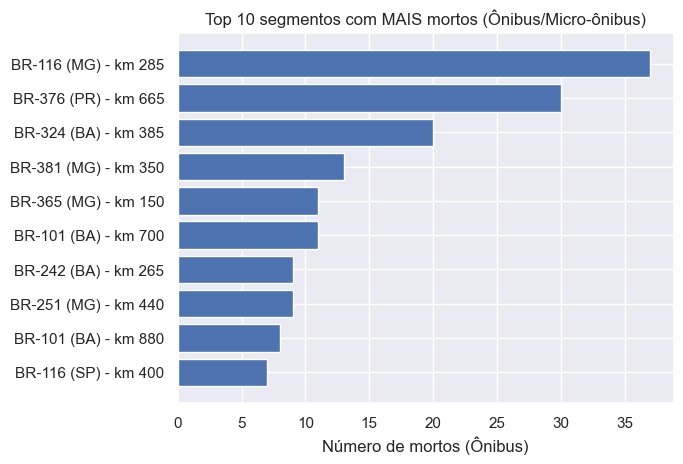

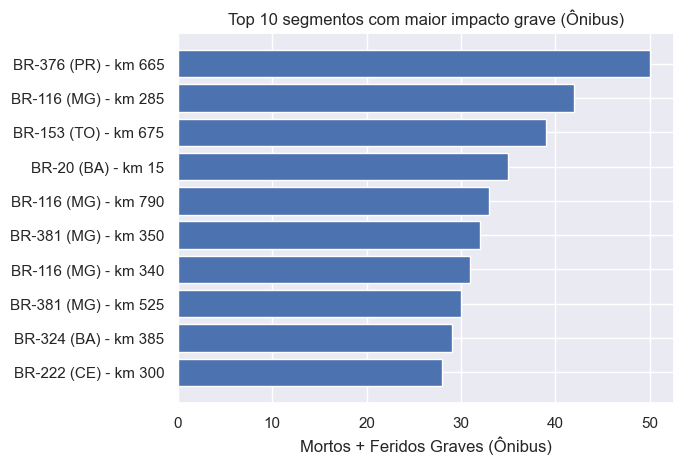

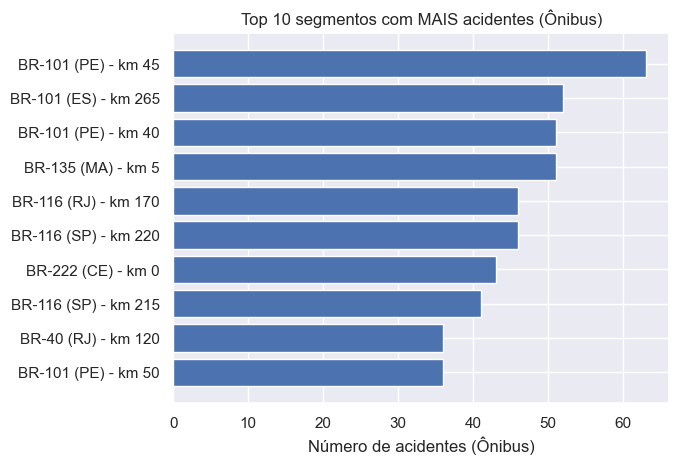

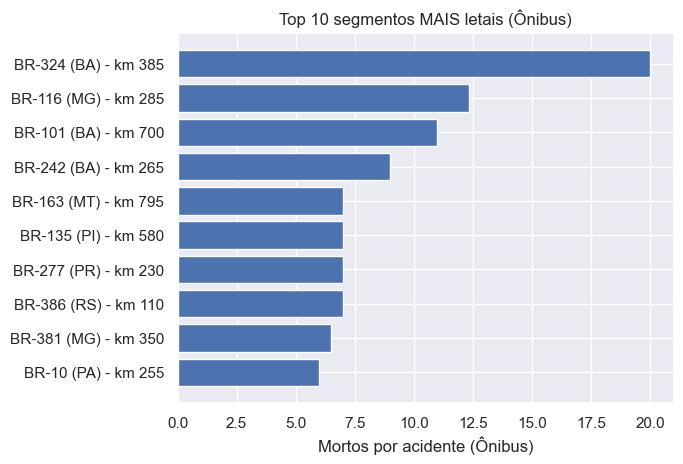

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =============================
# 1️⃣ Definir veículos
# =============================

onibus = ["Ônibus", "Micro-ônibus"]

# =============================
# 2️⃣ Filtrar base original
# =============================

df_onibus = df_filtrado[
    df_filtrado["tipo_veiculo"].isin(onibus)
].copy()

# Remover possíveis inconsistências
df_onibus = df_onibus.dropna(subset=["br", "uf", "km_bin"])

# =============================
# 3️⃣ Criar índice de severidade
# =============================

df_onibus["severity_index"] = (
    4 * df_onibus["Sum_Mortos"] +
    2 * df_onibus["Sum_Feridos_Graves"] +
    1 * df_onibus["Sum_Feridos_Leves"]
)

# =============================
# 4️⃣ Agrupar por segmento
# =============================

df_segmento_onibus = df_onibus.groupby(
    ["br", "uf", "km_bin"]
).agg(
    n_acidentes=("Sum_Total_Vitimas", "count"),
    total_mortos=("Sum_Mortos", "sum"),
    total_feridos_graves=("Sum_Feridos_Graves", "sum"),
    total_feridos_leves=("Sum_Feridos_Leves", "sum")
).reset_index()

# =============================
# 5️⃣ Criar nome do segmento
# =============================

df_segmento_onibus["segmento"] = (
    "BR-" + df_segmento_onibus["br"].astype(str) + " (" +
    df_segmento_onibus["uf"] + ") - km " +
    df_segmento_onibus["km_bin"].astype(str)
)

# =============================
# 6️⃣ TOP 10 - MAIS MORTOS
# =============================

top10_mortos_onibus = df_segmento_onibus.sort_values(
    "total_mortos", ascending=False
).head(10)

plt.figure()

plt.barh(
    top10_mortos_onibus["segmento"],
    top10_mortos_onibus["total_mortos"]
)

plt.xlabel("Número de mortos (Ônibus)")
plt.title("Top 10 segmentos com MAIS mortos (Ônibus/Micro-ônibus)")
plt.gca().invert_yaxis()

plt.show()

# =============================
# 7️⃣ TOP 10 - IMPACTO GRAVE
# =============================

df_segmento_onibus["impacto_grave"] = (
    df_segmento_onibus["total_mortos"] +
    df_segmento_onibus["total_feridos_graves"]
)

top10_impacto_onibus = df_segmento_onibus.sort_values(
    "impacto_grave", ascending=False
).head(10)

plt.figure()

plt.barh(
    top10_impacto_onibus["segmento"],
    top10_impacto_onibus["impacto_grave"]
)

plt.xlabel("Mortos + Feridos Graves (Ônibus)")
plt.title("Top 10 segmentos com maior impacto grave (Ônibus)")
plt.gca().invert_yaxis()

plt.show()

# =============================
# 8️⃣ TOP 10 - MAIS ACIDENTES
# =============================

top10_acidentes_onibus = df_segmento_onibus.sort_values(
    "n_acidentes", ascending=False
).head(10)

plt.figure()

plt.barh(
    top10_acidentes_onibus["segmento"],
    top10_acidentes_onibus["n_acidentes"]
)

plt.xlabel("Número de acidentes (Ônibus)")
plt.title("Top 10 segmentos com MAIS acidentes (Ônibus)")
plt.gca().invert_yaxis()

plt.show()

# =============================
# 9️⃣ EXTRA - TAXA DE RISCO
# =============================

df_segmento_onibus["mortos_por_acidente"] = (
    df_segmento_onibus["total_mortos"] /
    df_segmento_onibus["n_acidentes"].replace(0, np.nan)
)

top10_risco_onibus = df_segmento_onibus.sort_values(
    "mortos_por_acidente", ascending=False
).head(10)

plt.figure()

plt.barh(
    top10_risco_onibus["segmento"],
    top10_risco_onibus["mortos_por_acidente"]
)

plt.xlabel("Mortos por acidente (Ônibus)")
plt.title("Top 10 segmentos MAIS letais (Ônibus)")
plt.gca().invert_yaxis()

plt.show()